# SESIÓN 1:  CARGAR DATOS Y LIMPIEZA


## Diccionario de variables — California Housing (Kaggle)

Cada fila del dataset representa una **zona geográfica** (bloque censal), no una vivienda individual. Los valores son totales o medianas agregadas de todas las viviendas de esa zona.

| Columna | Descripción |
|---|---|
| `longitude` | Coordenada geográfica este-oeste de la zona. Valores negativos porque California está al oeste del meridiano de Greenwich. |
| `latitude` | Coordenada geográfica norte-sur de la zona. |
| `housing_median_age` | Antigüedad mediana de las viviendas en esa zona, en años. Un número alto indica un barrio con casas más antiguas/consolidadas. |
| `total_rooms` | Suma total de habitaciones (piezas en general, no solo dormitorios) de todas las viviendas de la zona. |
| `total_bedrooms` | Suma total de dormitorios de todas las viviendas de la zona. |
| `population` | Cantidad total de personas que viven en esa zona. |
| `households` | Cantidad de hogares (unidades familiares/viviendas ocupadas) en esa zona. |
| `median_income` | Ingreso mediano de los hogares de esa zona, expresado en decenas de miles de USD (ej. 8.3252 ≈ $83.252 USD). |
| `median_house_value` | Precio mediano de las viviendas en esa zona, en USD. **Variable objetivo (lo que vamos a predecir).** |
| `ocean_proximity` | Categoría de texto que describe la cercanía de la zona al mar/bahía (ej. NEAR BAY, INLAND, etc.). Única columna no numérica. |


## 1. Carga de datos y librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="darkgrid")

df = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto3_Prediccion_precio_viviedas/3)%20housing.csv")

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploración de nulos y duplicados

In [ ]:
#EXPLORACIÓN DE DATOS NULOS Y DUPLICADOS
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())
len(df)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Duplicados: 0


20640

## 3. Limpieza: eliminación de nulos y columnas irrelevantes (`latitude`, `longitude`)

In [ ]:
#ELIMINAREMOS LOS VALORES NULOS YA QUE ESTOS SON POCOS EN COMPARACIÓN DEL TOTAL (207 nulos sobre 20640 filas)
df = df.dropna()
len(df)
#ELIMINAREMOS COLUMNAS LATITUD Y LONGITUD YA QUE NO NOS SIRVEN PARA ESTE EJERCICIO DE REGRESIÓN LINEAL
df = df.drop(["latitude", "longitude"], axis=1)


df.head()


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Exploración de la variable categórica `ocean_proximity`

In [ ]:
valores_distintos = df["ocean_proximity"].unique()
valores_distintos

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

## 5. Codificación de variables categóricas (Dummies)

In [ ]:
# CONVERTIMOS LA COLUMNA DE PROXIMIDAD AL OCÉANO EN DUMMIES
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

columnas_dummy = ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
df[columnas_dummy] = df[columnas_dummy].astype(int)

df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


# SESIÓN 2: ENTRENAMIENTO DEL MODELO Y ANALISIS ESTADÍSTICOS


## 1. Definición de X e y, separación train/test

In [ ]:
# DEFINIMOS LAS VARIABLES DEPENDIENTES Y LA VARIABLE OBJETIVO
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

print("Entrenamiento:", X_entrenamiento.shape)
print("Prueba:", X_prueba.shape)

Entrenamiento: (16346, 10)
Prueba: (4087, 10)


## 2. Entrenamiento del modelo de Regresión Lineal (Scikit-Learn)

In [ ]:
#ENTRENAMIENTO DE MODELO DE REGRESIÓN LINEAL
modelo = LinearRegression()
modelo.fit(X_entrenamiento, y_entrenamiento)

LinearRegression()

## 3. Coeficientes e intercepto

In [ ]:
print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Coeficientes: [ 1.19694834e+03 -7.59462774e+00  8.43173854e+01 -3.53424176e+01
  6.93438524e+01  4.04986205e+04 -6.82909473e+04  2.34424148e+05
  2.35159986e+03  1.23654921e+04]
Intercepto: 25716.913386251603


## 4. Verificación de `ocean_proximity_ISLAND` (pocos casos)

In [ ]:
#VERIFICACIÓN DE CANTIDAD DE VARIABLES ocean_proximity_ISLAND, YA QUE SU COEF ES MUY ALTO.
contar_cantidad_de_valores_island = (df["ocean_proximity_ISLAND"] == 1).sum()
contar_cantidad_de_valores_island

np.int64(5)

## 5. Interpretación estadística con StatsModels (p-values, R², intervalos de confianza)

In [ ]:
#EJECUTAMOS EL MODELO Y REVISAMOS LOS VALORES ESTADÍSTICOS
X_con_constante = sm.add_constant(X_entrenamiento)
modelo_stats = sm.OLS(y_entrenamiento, X_con_constante).fit()
print(modelo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     2821.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:53:37   Log-Likelihood:            -2.0548e+05
No. Observations:               16346   AIC:                         4.110e+05
Df Residuals:                   16335   BIC:                         4.111e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## 6. Diagnóstico de Multicolinealidad (VIF)

In [ ]:
#CALCULAMOS EL VALOR VIF
resultados_vif = {}

for columna in X_entrenamiento.columns:
    y_var = X_entrenamiento[columna]
    x_var = X_entrenamiento.drop(columna, axis=1)

    modelo_aux = LinearRegression()
    modelo_aux.fit(x_var, y_var)
    r2 = modelo_aux.score(x_var, y_var)

    vif = 1 / (1 - r2)
    resultados_vif[columna] = round(vif, 2)

resultados_vif

{'housing_median_age': 1.31,
 'total_rooms': 12.62,
 'total_bedrooms': 34.11,
 'population': 6.1,
 'households': 32.46,
 'median_income': 1.75,
 'ocean_proximity_INLAND': 1.44,
 'ocean_proximity_ISLAND': 1.0,
 'ocean_proximity_NEAR BAY': 1.19,
 'ocean_proximity_NEAR OCEAN': 1.14}

## 7. Corrección: Feature Engineering (variables por hogar)

In [ ]:
# Entrenamiento
X_entrenamiento['rooms_per_household'] = X_entrenamiento['total_rooms'] / X_entrenamiento['households']
X_entrenamiento['bedrooms_per_household'] = X_entrenamiento['total_bedrooms'] / X_entrenamiento['households']
X_entrenamiento['population_per_household'] = X_entrenamiento['population'] / X_entrenamiento['households']
X_entrenamiento = X_entrenamiento.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

# Prueba (mismo tratamiento, obligatorio para que calcen las columnas)
X_prueba['rooms_per_household'] = X_prueba['total_rooms'] / X_prueba['households']
X_prueba['bedrooms_per_household'] = X_prueba['total_bedrooms'] / X_prueba['households']
X_prueba['population_per_household'] = X_prueba['population'] / X_prueba['households']
X_prueba = X_prueba.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

X_entrenamiento.head()

,housing_median_age,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_household,population_per_household
17727,14.0,4.7027,0,0,0,0,4.951740,1.037037,3.028058
2057,33.0,3.4107,1,0,0,0,5.954023,1.040230,3.563218
6453,25.0,3.6639,1,0,0,0,5.126482,1.117260,2.434783
4619,28.0,2.2364,0,0,0,0,2.642058,1.061521,3.086130
15266,27.0,3.5500,0,0,0,1,4.551980,0.970297,3.222772


## 8. VIF recalculado tras el Feature Engineering

In [ ]:
#GENERAMOS NUEVOS VALORES VIF CON LAS NUEVAS VARIABLES
resultados_vif_nuevo = {}

for columna in X_entrenamiento.columns:
    y_var = X_entrenamiento[columna]
    x_var = X_entrenamiento.drop(columna, axis=1)

    modelo_aux = LinearRegression()
    modelo_aux.fit(x_var, y_var)
    r2 = modelo_aux.score(x_var, y_var)

    vif = 1 / (1 - r2)
    resultados_vif_nuevo[columna] = round(vif, 2)

resultados_vif_nuevo

{'housing_median_age': 1.16,
 'median_income': 2.56,
 'ocean_proximity_INLAND': 1.48,
 'ocean_proximity_ISLAND': 1.0,
 'ocean_proximity_NEAR BAY': 1.17,
 'ocean_proximity_NEAR OCEAN': 1.13,
 'rooms_per_household': 7.8,
 'bedrooms_per_household': 6.6,
 'population_per_household': 1.0}

## 9. Matriz de correlación de las nuevas variables

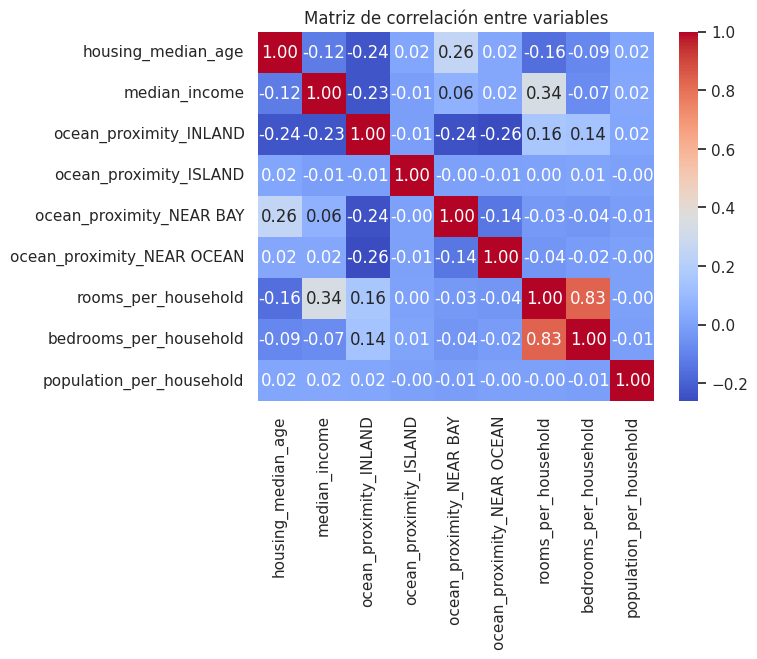

In [ ]:
#EXISTE UNA ALTA MULTICOLINEALIDAD DE rooms_per_household Y bedrooms_per_household, HACEMOS UNA MATRIZ DE CORRELACIÓN PARA VER ALGUNOS INDICIOS

matriz_correlacion = X_entrenamiento.corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables')
plt.show()

## 10. Reentrenamiento del modelo con las variables corregidas

In [ ]:
#EJECUTAMOS EL NUEVO MODELO Y REVISAMOS LOS VALORES ESTADÍSTICOS

X_con_constante_nuevo = sm.add_constant(X_entrenamiento)
modelo_stats_nuevo = sm.OLS(y_entrenamiento, X_con_constante_nuevo).fit()
print(modelo_stats_nuevo.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2802.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:53:38   Log-Likelihood:            -2.0605e+05
No. Observations:               16346   AIC:                         4.121e+05
Df Residuals:                   16336   BIC:                         4.122e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## 11. Diagnóstico de Normalidad de los residuos (Jarque-Bera)

**Nota — normalidad de los residuos:** el test de Jarque-Bera Prob(JB) ≈ 0.00 indica que los residuos **no siguen una distribución normal** (skew positivo, kurtosis alta). Esto no invalida el modelo ni descarta el uso de otras herramientas estadísticas: solo significa que los p-values e intervalos de confianza calculados son aproximados, no exactos. Con una muestra grande (>15.000 filas) esta aproximación sigue siendo razonablemente confiable. Además, sigue existiendo multicolinealidad residual moderada entre rooms_per_household y bedrooms_per_household (VIF ≈ 7-8), ya mejorada respecto al modelo original pero no eliminada del todo.

## 12. Gráfico de Residuos vs Predicciones (Homocedasticidad)

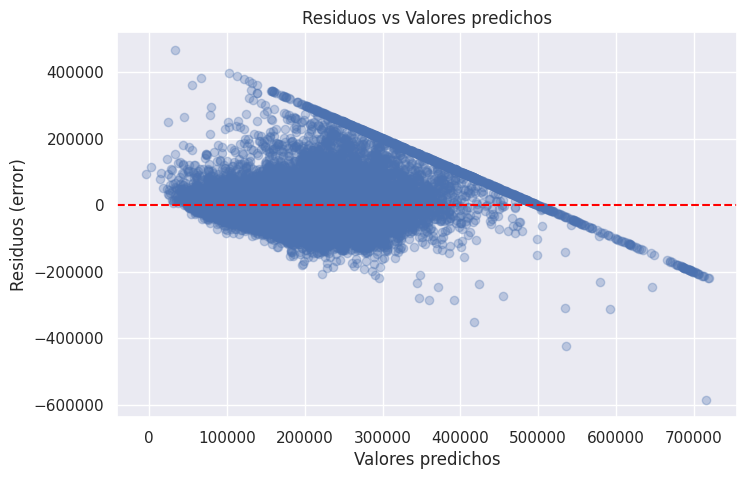

In [ ]:
#Graficamos los residuos del modelo para evaluar visualmente si existen indicios de homocedasticidad.

predicciones = modelo_stats_nuevo.predict(X_con_constante_nuevo)
residuos = y_entrenamiento - predicciones

plt.figure(figsize=(8, 5))
plt.scatter(predicciones, residuos, alpha=0.3, color='#4C72B0')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos (error)')
plt.title('Residuos vs Valores predichos')
plt.show()

**Nota — hallazgo de la línea diagonal:** el gráfico anterior muestra una recta casi perfecta superpuesta a la nube de puntos. Corresponde a **958 filas (4.7% del dataset)** con `median_house_value` fijado exactamente en **$500.001** — un techo artificial del registro censal original, no el precio real de esas zonas (censura de datos). Como el "precio real" de esas filas es una constante, su residuo es `500.001 - predicción`, lo que genera matemáticamente una recta perfecta de pendiente -1 y distorsiona tanto los coeficientes como el diagnóstico de residuos. Se eliminan a continuación.

## 13. Corrección: eliminación de datos censurados ($500.001)

In [ ]:
# Eliminamos las viviendas con precio topado en $500.001 (censura de datos)

df = df[df['median_house_value'] != 500001.0]
len(df)

19475

## 14. Reentrenamiento del modelo sin datos censurados

In [ ]:
#HACEMOS EL OTRO MODELO PARA PODER CORREGIR EL ANTERIOR CON ESTOS VALORES EXTRAÑOS

# 2. Definir X, y y volver a hacer el split
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature engineering (rooms/bedrooms/population per household)
X_entrenamiento['rooms_per_household'] = X_entrenamiento['total_rooms'] / X_entrenamiento['households']
X_entrenamiento['bedrooms_per_household'] = X_entrenamiento['total_bedrooms'] / X_entrenamiento['households']
X_entrenamiento['population_per_household'] = X_entrenamiento['population'] / X_entrenamiento['households']
X_entrenamiento = X_entrenamiento.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

X_prueba['rooms_per_household'] = X_prueba['total_rooms'] / X_prueba['households']
X_prueba['bedrooms_per_household'] = X_prueba['total_bedrooms'] / X_prueba['households']
X_prueba['population_per_household'] = X_prueba['population'] / X_prueba['households']
X_prueba = X_prueba.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

# 4. Reentrenar el modelo con statsmodels
X_con_constante_nuevo = sm.add_constant(X_entrenamiento)
modelo_stats_nuevo = sm.OLS(y_entrenamiento, X_con_constante_nuevo).fit()
print(modelo_stats_nuevo.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     2259.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:54:18   Log-Likelihood:            -1.9458e+05
No. Observations:               15580   AIC:                         3.892e+05
Df Residuals:                   15570   BIC:                         3.893e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

**Nota — coherencia estadística tras el filtro:** el R² del modelo bajó de 0.607 a 0.566 al quitar las 958 filas censuradas. Esto es esperable y es una buena señal, no un empeoramiento real: esas filas compartían todas el mismo valor exacto, lo que inflaba artificialmente el ajuste. El Condition Number también mejoró (de 2.360 a 1.770), y todos los p-values se mantienen en 0.000 — el modelo queda más chico en R² pero más honesto.

## 15. Nuevo gráfico de Residuos (verificación de Homocedasticidad)

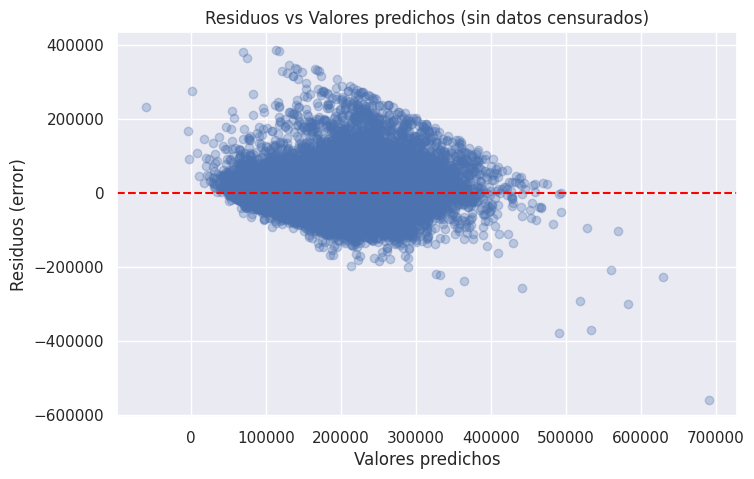

In [ ]:
predicciones = modelo_stats_nuevo.predict(X_con_constante_nuevo)
residuos = y_entrenamiento - predicciones

plt.figure(figsize=(8, 5))
plt.scatter(predicciones, residuos, alpha=0.3, color='#4C72B0')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos (error)')
plt.title('Residuos vs Valores predichos (sin datos censurados)')
plt.show()

**Nota — lectura del gráfico sin censura:** la línea diagonal desapareció, confirmando que era causada por los datos censurados. Sin embargo, la nube de puntos conserva forma de embudo (mayor dispersión en precios bajos-medios, menor en precios altos): la heterocedasticidad es un patrón real de los datos, no un artefacto de la censura. Se confirma formalmente a continuación con un test estadístico.

## 16. Test formal de heterocedasticidad (Breusch-Pagan)

In [ ]:
#CONFIRMAMOS LA HETEROCEDASTICIDAD
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(modelo_stats_nuevo.resid, X_con_constante_nuevo)

etiquetas = ['Estadístico LM', 'p-value LM', 'Estadístico F', 'p-value F']
resultado_bp = dict(zip(etiquetas, bp_test))
resultado_bp

{'Estadístico LM': np.float64(904.2542895147461),
 'p-value LM': np.float64(7.495683025868341e-189),
 'Estadístico F': np.float64(106.5949186992818),
 'p-value F': np.float64(1.1889574715552409e-194)}

El modelo tiene heterocedasticidad

## 17. Evaluación final del modelo (RMSE, MAE, R² en datos de prueba)

In [ ]:
#Cálculo de MAE, RMSE, R2 Y EJECUCIÓN DEL MODELO CON LOS DATOS RESTANTES A LOS DE PRUEBA (20% DE LOS DATOS SE DEJARON PARA EVALUAR EL MODELO)
X_prueba_con_constante = sm.add_constant(X_prueba)
predicciones_prueba = modelo_stats_nuevo.predict(X_prueba_con_constante)

rmse = mean_squared_error(y_prueba, predicciones_prueba) ** 0.5
mae = mean_absolute_error(y_prueba, predicciones_prueba)
r2_prueba = r2_score(y_prueba, predicciones_prueba)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² (en datos de prueba):", r2_prueba)
print("Ratio RMSE/MAE:", rmse / mae)

RMSE: 63446.69678024737
MAE: 46751.14093039988
R² (en datos de prueba): 0.5843618750351487
Ratio RMSE/MAE: 1.3571154739240003


**Nota — coherencia entrenamiento vs. prueba:** el R² en datos de prueba (0.584) resultó similar (incluso levemente superior) al de entrenamiento (0.566). Esto indica que el modelo **no está sobreajustado**: generaliza razonablemente bien a datos que nunca vio. El MAE (~$46.751) da una magnitud de error interpretable en dólares, y el ratio RMSE/MAE (1.36) es moderado, coherente con una heterocedasticidad presente pero no extrema.

## 18. Regularización: RidgeCV y LassoCV

In [ ]:
#APLICACIÓN DE RIDGE Y LASSO
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np

escalador = StandardScaler()
X_entrenamiento_escalado = escalador.fit_transform(X_entrenamiento)
X_prueba_escalado = escalador.transform(X_prueba)

alphas_a_probar = np.logspace(-2, 5, 50)

modelo_ridge_cv = RidgeCV(alphas=alphas_a_probar)
modelo_ridge_cv.fit(X_entrenamiento_escalado, y_entrenamiento)

modelo_lasso_cv = LassoCV(alphas=alphas_a_probar, max_iter=10000)
modelo_lasso_cv.fit(X_entrenamiento_escalado, y_entrenamiento)

print("Mejor alpha Ridge:", modelo_ridge_cv.alpha_)
print("Mejor alpha Lasso:", modelo_lasso_cv.alpha_)

pred_ridge = modelo_ridge_cv.predict(X_prueba_escalado)
pred_lasso = modelo_lasso_cv.predict(X_prueba_escalado)

print("\n--- Ridge ---")
print("RMSE:", mean_squared_error(y_prueba, pred_ridge) ** 0.5)
print("MAE:", mean_absolute_error(y_prueba, pred_ridge))
print("R²:", r2_score(y_prueba, pred_ridge))

print("\n--- Lasso ---")
print("RMSE:", mean_squared_error(y_prueba, pred_lasso) ** 0.5)
print("MAE:", mean_absolute_error(y_prueba, pred_lasso))
print("R²:", r2_score(y_prueba, pred_lasso))

print("\nCoeficientes Lasso:", modelo_lasso_cv.coef_)

Mejor alpha Ridge: 100.0
Mejor alpha Lasso: 1389.4954943731361

--- Ridge ---
RMSE: 63468.12246964705
MAE: 46806.76137382952
R²: 0.58408110905465

--- Lasso ---
RMSE: 64110.58466551035
MAE: 47466.749888525526
R²: 0.5756181328710621

Coeficientes Lasso: [  8357.815406    55950.33489812 -31745.16032869   2025.49965403
   1902.15049654   3688.95612504     -0.           1205.41244711
  -1663.97518144]


## Conclusión del proyecto

Tras eliminar las observaciones censuradas en **\$500.001**, el modelo de regresión lineal obtuvo un **RMSE de \$63.447**, un **MAE de \$46.751** y un **R² de 0.584** sobre el conjunto de prueba. En términos prácticos, esto significa que el modelo se equivoca en promedio en unos **\$47.000** al estimar el precio de una vivienda, y logra explicar cerca del **58 % de la variabilidad** de los precios usando únicamente variables demográficas y estructurales de la zona, sin considerar características propias de cada vivienda como la calidad de construcción, el estado de conservación o la vista.

Como parte del análisis también se probaron modelos con regularización (**Ridge** y **Lasso**), optimizando el parámetro `alpha` mediante validación cruzada. Ninguno logró superar a la regresión lineal tradicional: Ridge (alpha = 100) entregó resultados prácticamente idénticos, mientras que Lasso (alpha ≈ 1389) fue ligeramente peor en las tres métricas.

Un resultado interesante fue que **Lasso eliminó únicamente la variable `rooms_per_household`**, asignándole un coeficiente igual a cero. Esto coincide con lo observado antes en la matriz de correlación y en el **Factor de Inflación de la Varianza (VIF)**: esa variable compartía gran parte de su información con `bedrooms_per_household` (VIF de 7.8 y 6.6 respectivamente). Esto también ayuda a explicar por qué la regularización no aportó mejoras: la multicolinealidad remanente era moderada y, además, con unas 15.500 observaciones para solo 9 variables, hay datos de sobra para estimar los coeficientes sin necesidad de penalización.

## Limitaciones del modelo

Aunque el desempeño del modelo es aceptable, durante el análisis se detectaron dos supuestos de la regresión lineal que no se cumplen del todo.

### 1. No normalidad de los residuos

Los residuos no siguen una distribución normal, lo que se confirmó con el **test de Jarque-Bera** (*p-value* cercano a cero) y con una asimetría positiva (Skew = 1.06), es decir, el modelo tiende a quedarse corto con más frecuencia en las zonas de precios altos. Esto implica que los intervalos de confianza y los valores *p* de los coeficientes deben leerse como aproximaciones. De todas formas, con más de **15.000 observaciones** de entrenamiento, el impacto práctico de esta limitación es reducido gracias al Teorema Central del Límite.

### 2. Presencia de heterocedasticidad

También se detectó **heterocedasticidad**, tanto en la inspección visual del gráfico de residuos, que muestra un patrón en forma de embudo que se abre hacia los valores predichos más altos, como en el **test de Breusch-Pagan** (*p-value* cercano a cero).

Esto indica que la variabilidad del error no es constante: **el error absoluto crece junto con el precio de la vivienda**. En las zonas más baratas el modelo se equivoca en torno a \$34.000 en promedio, mientras que en las más caras el error promedio sube a unos \$58.000. Por eso, en un contexto real, las predicciones sobre viviendas de mayor valor son las que deben interpretarse con mayor cautela en términos de dólares.

En conjunto, estas limitaciones no invalidan el modelo, ya que es habitual que los datos reales no cumplan a la perfección todos los supuestos de la regresión lineal, pero sí deben tenerse presentes al interpretar los resultados y marcan un camino claro de mejora. Una alternativa prometedora para una próxima iteración es aplicar una **transformación logarítmica al precio de la vivienda** antes de entrenar, una técnica muy usada para reducir la asimetría de la variable objetivo y mitigar la heterocedasticidad.